## Atmospheric Methane Trends

NOAA Global Monitoring Laboratory Atmospheric Methane trend data.

Source: [gml.noaa.gov/ccgg/trends_ch4/](https://gml.noaa.gov/ccgg/trends_ch4/). For the CSV files,
see [Trends in Atmospheric Methane data](https://gml.noaa.gov/ccgg/trends_ch4/).

Citation: Dr. Pieter Tans, NOAA/GML (gml.noaa.gov/ccgg/trends/) and Dr. Ralph Keeling, Scripps Institution of
Oceanography (scrippsco2.ucsd.edu/).

This notebook will look for the monthly CH<sub>r</sub> data from NOAA, and if missing or more than 1 day old,
it will download the latest data from the NOAA website.  This can fail, requiring you to retrieve the data by
hand, or `touch` and older file to suppress download.

In [6]:
%matplotlib inline

import os, time
import urllib.request

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, LogLocator, NullFormatter

import warnings
warnings.filterwarnings('ignore',category=UserWarning, append=True)

## Standard Plot Format

Setup the standard plotting format and make the plot.  

#### Aspect Ratio

`aspect` sets the aspect ratio, width/height.  The default aspect ratio is 4:3, 1:1 for square plots, 
and 5:2 (2.5:1) for spectra, and equal aspect ratio for images and plots of Cartesian coordinates.
Use a formula instead of decimal when the result is a fraction (example: `aspect = 4.0/3.0` instead of
`aspect=1.33`).

In [7]:
aspect = 1.5 # 4.0/3.0 

#
# Don't change these unless you really need to (we never have)
#
# fPage is the horizontal fraction of the page occupied by the figure, default 1.0
#
# scaleFac is the LaTeX includegraphics scaling in units of \textwidth, default 1.0
#

fPage = 1.0
scaleFac = 0.85

# Text width in inches - don't change, this is defined by the print layout

textWidth = 6.0 # inches

# Graphic dimensions depending on bitmap or vector format (draft vs production)

figFmt = 'png'
dpi = 600
plotWidth = dpi*fPage*textWidth
plotHeight = plotWidth/aspect
axisFontSize = 10
labelFontSize = 7
lwidth = 0.5
axisPad = 5
wInches = fPage*textWidth # float(plotWidth)/float(dpi)
hInches = wInches/aspect  # float(plotHeight)/float(dpi)
    
axisFontSize = np.rint(axisFontSize/scaleFac)
labelFontSize = np.rint(labelFontSize/scaleFac)

# LaTeX is used throughout for markup of symbols, Times-Roman serif font

plt.rc('text', usetex=True)
plt.rc('font', **{'family':'serif','serif':['Times-Roman'],'weight':'bold','size':'16'})

# Font and line weight defaults for axes

matplotlib.rc('axes',linewidth=lwidth)
matplotlib.rcParams.update({'font.size':axisFontSize})

# axis and label padding

plt.rcParams['xtick.major.pad']=f'{axisPad}'
plt.rcParams['ytick.major.pad']=f'{axisPad}'
plt.rcParams['axes.labelpad'] = f'{axisPad}'

## NOAA Methane Data

Monthly data beginning in July 1983 through the latest update.

Source data in file `ch4_mm_gl.csv` which has many columns. We plot
 * `decimal` - year+month in decimal form
 * `average` = monthly averaged CH4 in ppm
 * `trend` = interpolated trend line in ppm

### Retrieve the latest CH<sub>4</sub> data from NOAA

See if there is a file named 'ch4_mm_gl.csv' in the current working directory.  If none or more than 1 day old,
try to download it from the NOAA GML website to update it.

You can force update by setting `updateFile = True`

In [8]:
dataURL = 'https://gml.noaa.gov/webdata/ccgg/trends/ch4/ch4_mm_gl.csv'
ch4File = 'ch4_mm_gl.csv'

updateFile = False # set True to force updates

oldFile = False
if not os.path.exists(ch4File):
    updateFile = True
    oldFile = False
else:
    oldFile = True
    fileAge = (time.time() - os.path.getmtime(ch4File))/86400.0
    if fileAge >= 1.0:
        updateFile = True
        
if updateFile:
    try:
        with urllib.request.urlopen(dataURL) as wf:
            raw = wf.read().decode('utf-8')
    except:
        if oldFile:
            print('Problem retrieving updated data, using old file')
        else:
            print('Problem retrieving updated data, no old file to use')
            print('Try retrieving by hand and re-run')
    if oldFile:
        os.remove(ch4File)
    f = open(ch4File,'w')
    f.write(raw)
    f.close()   
    print('Retrieved updated CH4 data from NOAA')
else:
    print('CH4 data from NOAA are up-to-date (<1d old)')

CH4 data from NOAA are up-to-date (<1d old)


### Read the data file

Data are in CSV format. 

The `average` column is the monthly value which shows a sinusoidal pattern due to seasonal uptake and release of
CO2 by vegetation. 

The `deseasonalized` column shows the general trend in CO2 concentration with the seasonal component subtracted. Note that older data from this website used `interpolated` instead of `deseasonalized` for that data.

In [9]:
title = r'Global Average Atmospheric CH$_4$'
source = 'Scripps Institution of Oceanography\n NOAA Global Monitoring Laboratory'
srcURL = 'https://gml.noaa.gov/ccgg/trends_ch4/'

data = pd.read_csv(ch4File,comment='#')
year = np.array(data['year'])
month = np.array(data['month'])
date = np.array(data['decimal'])
ch4ppb = np.array(data['average'])  # monthly average CH4 in ppb
trend = np.array(data['trend']) # interpolated trendline

# find the maximum CO2 concentration and date

monthNames = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

ch4Max = np.max(ch4ppb)
idx = np.argmax(ch4ppb)
maxDate = f'{monthNames[month[idx]-1]} {year[idx]}'
maxCH4 = f'Maximum CH$_4$ concentration\n {ch4Max:.0f} ppb measured {maxDate}'

print(f'Maximum CH4 concentration is {ch4Max:.2f} ppb measured in {maxDate}')

plotFile = f'NOAA_AtmosCH4_Global_{year[-1]}.png' 

Maximum CH4 concentration is 1941.70 ppb measured in Oct 2024


### Make the plot

Plot monthly globally-averaged CH4 in ppb vs time.

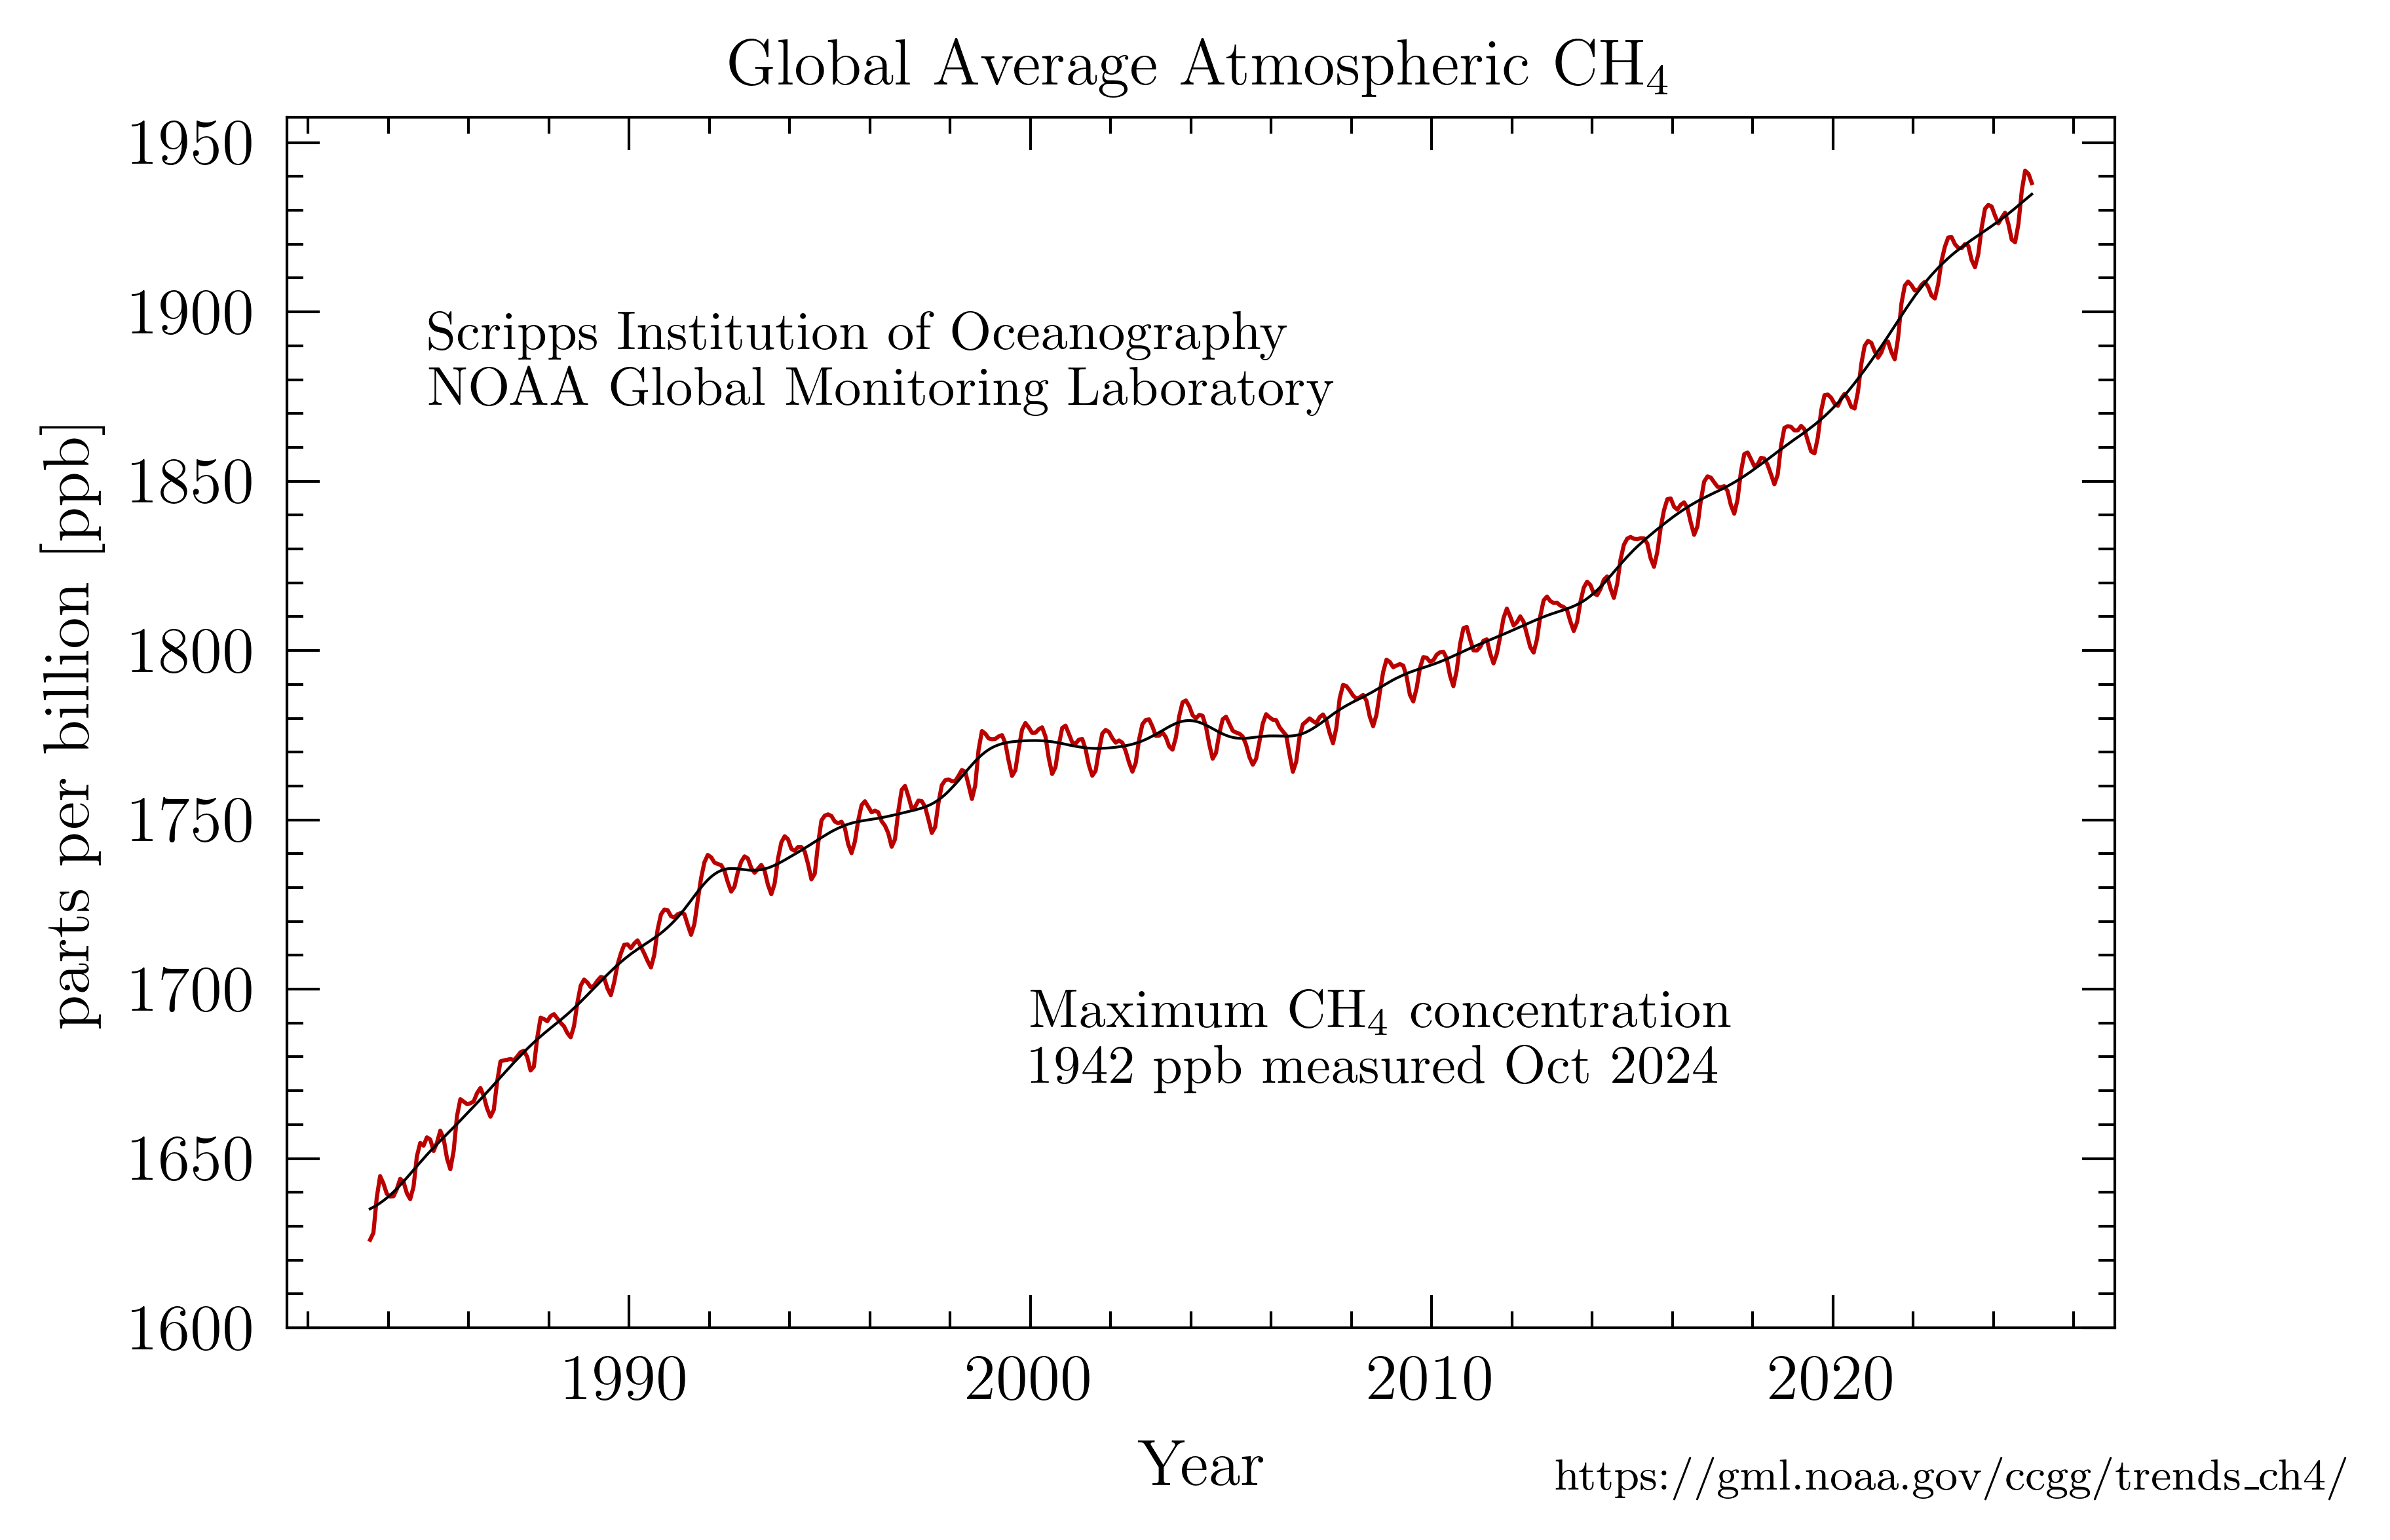

In [10]:
fig,ax = plt.subplots(figsize=(wInches,hInches),dpi=dpi)

ax.tick_params('both',length=6,width=lwidth,which='major',direction='in',top='on',right='on')
ax.tick_params('both',length=3,width=lwidth,which='minor',direction='in',top='on',right='on')

# Limits

dt = np.max(date)-np.min(date)
yrMin = np.min(date) - 0.05*dt
yrMax = np.max(date) + 0.05*dt

dppb = np.max(ch4ppb)-np.min(ch4ppb)
ch4Min = 1600.0 # np.min(ch4ppb) - 0.05*dppb
ch4Max = np.max(ch4ppb) + 0.05*dppb


plt.xlim(yrMin,yrMax)
ax.xaxis.set_major_locator(MultipleLocator(10))
ax.xaxis.set_minor_locator(MultipleLocator(2))
plt.xlabel(r'Year',fontsize=axisFontSize)

plt.ylim(ch4Min,ch4Max)
ax.yaxis.set_major_locator(MultipleLocator(50))
ax.yaxis.set_minor_locator(MultipleLocator(10))
plt.ylabel(r'parts per billion [ppb]',fontsize=axisFontSize)

plt.plot(date,ch4ppb,ls='-',color='#bb0000',lw=0.75,zorder=10)
plt.plot(date,trend,ls='-',color='black',lw=0.5,zorder=10)
plt.title(title,fontsize=axisFontSize)

# Data Source

plt.text(1985,1900,source,va='top',ha='left',fontsize=10)
plt.text(1.0, 0.0, srcURL, fontsize=8, ha='right',va='bottom',transform=plt.gcf().transFigure)

# Maximum CH4 concentration

plt.text(2000,1700,maxCH4,va='top',ha='left',fontsize=10)

# Make the plot

plt.savefig(plotFile,bbox_inches='tight',facecolor='white')

plt.show()